In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')


In [3]:
df = pd.read_csv("../data/bank.csv", sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [5]:
df.shape

(4521, 17)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [9]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


In [11]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [15]:
df['y'].value_counts()

y
no     4000
yes     521
Name: count, dtype: int64

In [17]:
conversion_rate = (df['y'].value_counts()['yes'] / len(df))*100

print("Conversion Rate:", round(conversion_rate,2),"%")

Conversion Rate: 11.52 %


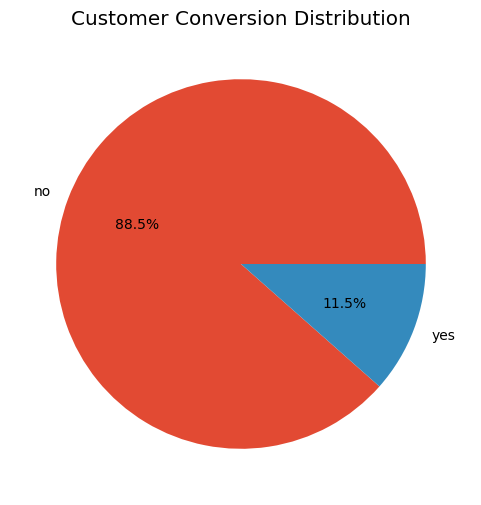

In [19]:
df['y'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Customer Conversion Distribution")
plt.ylabel("")
plt.show()

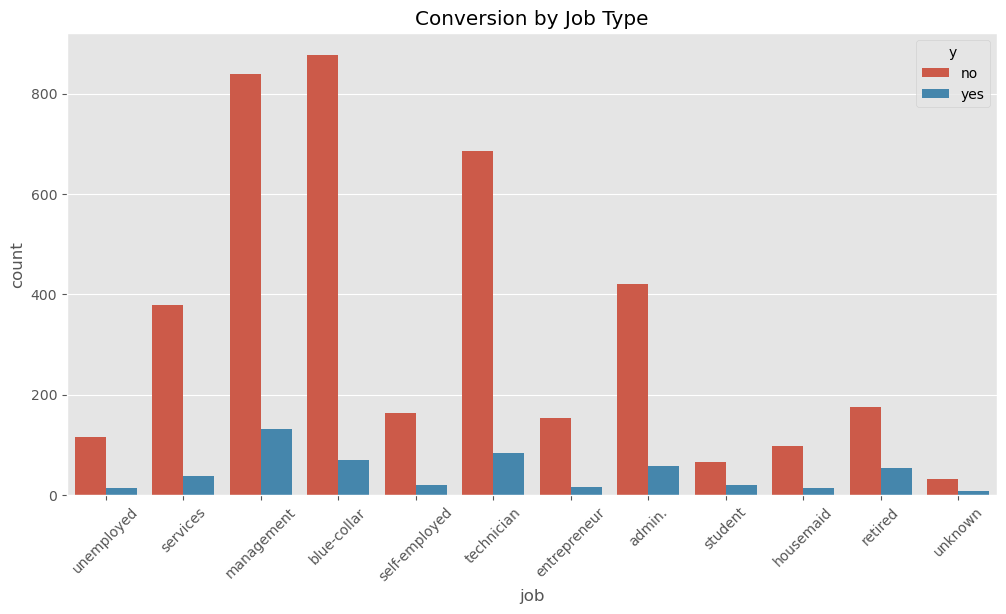

In [21]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='job',
    hue='y',
    data=df
)

plt.xticks(rotation=45)
plt.title("Conversion by Job Type")
plt.show()

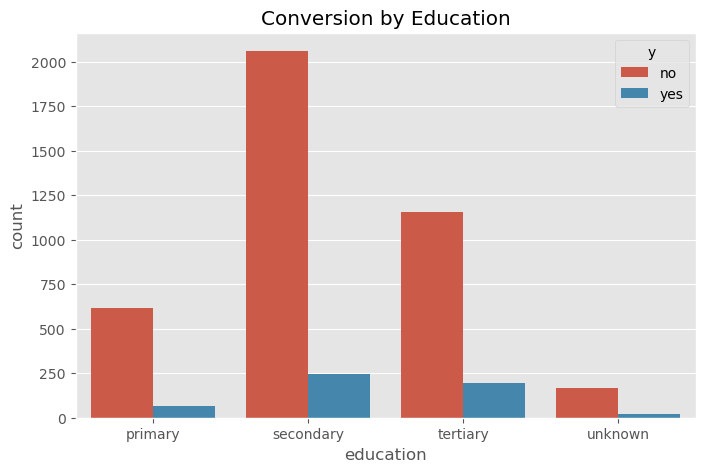

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='education',
    hue='y',
    data=df
)

plt.title("Conversion by Education")
plt.show()

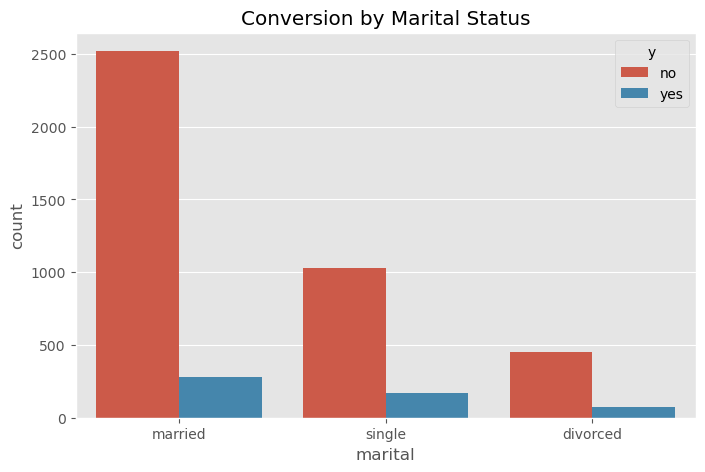

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='marital',
    hue='y',
    data=df
)

plt.title("Conversion by Marital Status")
plt.show()

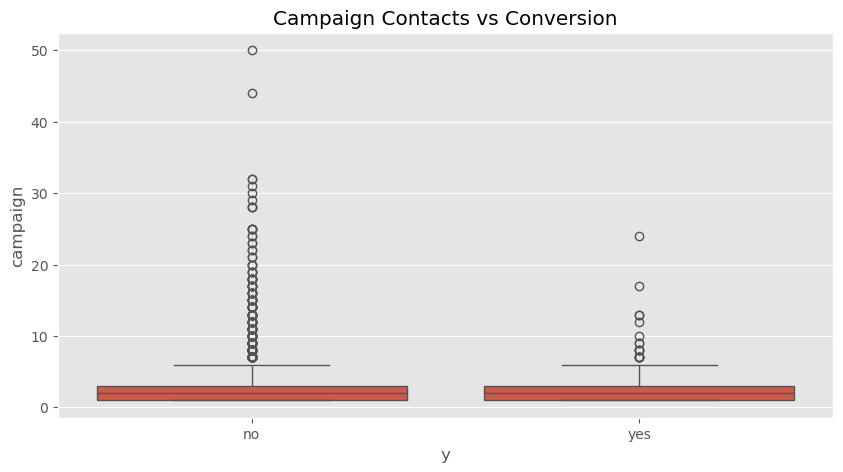

In [29]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='y',
    y='campaign',
    data=df
)

plt.title("Campaign Contacts vs Conversion")
plt.show()

In [31]:
visitors = len(df)

leads = len(df[df['contact'] != 'unknown'])

customers = len(df[df['y']=='yes'])

print("Visitors:", visitors)
print("Leads:", leads)
print("Customers:", customers)

Visitors: 4521
Leads: 3197
Customers: 521


In [33]:
visitor_to_lead = (leads/visitors)*100

lead_to_customer = (customers/leads)*100

print("Visitor to Lead:", round(visitor_to_lead,2),"%")

print("Lead to Customer:", round(lead_to_customer,2),"%")

Visitor to Lead: 70.71 %
Lead to Customer: 16.3 %


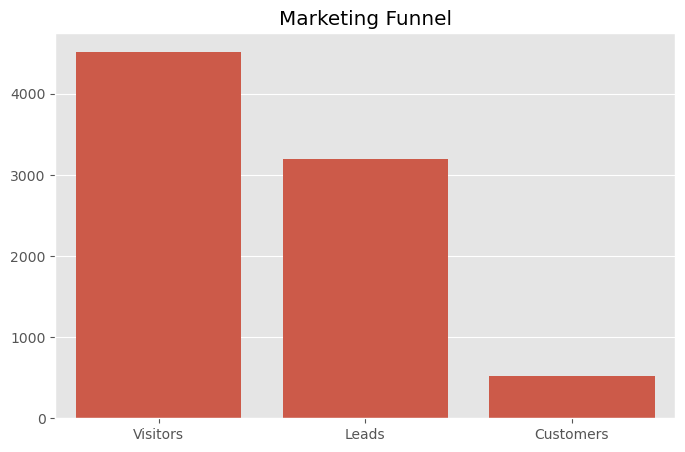

In [35]:
stages = ['Visitors','Leads','Customers']

values = [visitors,leads,customers]

plt.figure(figsize=(8,5))

sns.barplot(
    x=stages,
    y=values
)

plt.title("Marketing Funnel")
plt.show()

In [37]:
drop_off = ((leads-customers)/leads)*100

print("Drop Off Rate:", round(drop_off,2),"%")

Drop Off Rate: 83.7 %


Insight 1

Majority of customers do not convert.

Insight 2

Certain job categories show better conversion.

Insight 3

Contact method impacts success rate.

Insight 4

Large drop-off occurs between lead and customer stages.

Recommendation 1

Focus marketing on high-converting customer segments.

Recommendation 2

Improve follow-up campaigns.

Recommendation 3

Reduce lead drop-off through personalized communication.

Recommendation 4

Optimize underperforming channels.

The analysis identified major drop-off points and conversion opportunities. By targeting high-performing customer segments and improving campaign effectiveness, overall conversion rates can be increased.

In [42]:
plt.savefig("../images/chart_name.png")

<Figure size 640x480 with 0 Axes>